# 노트북 13 — QFT와 주기 찾기

목표: Quantum Fourier Transform(QFT)을 직접 만들어 보고, 그것을 order finding의 핵심 도구로 바라보며, 주기 구조가 스펙트럼 peak로 떠오르는 모습을 확인합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pqc_edu.quantum.simulator import QuantumState, H
from pqc_edu.quantum.circuits import qft, inverse_qft, qft_matrix

## 한 줄의 식으로 보는 QFT

$$\text{QFT}|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i jk / N} |k\rangle$$

여기서 $N=2^n$입니다. 고전적인 Discrete Fourier Transform과 같은 식이며, 다만 샘플이 아니라 진폭에 작용한다는 점만 다릅니다.

In [2]:
print('1-qubit QFT = Hadamard?', np.allclose(qft_matrix(1), H))
print('\n2-qubit QFT matrix:')
print(np.round(qft_matrix(2), 3))

1-qubit QFT = Hadamard? True

2-qubit QFT matrix:
[[ 0.5+0.j   0.5+0.j   0.5+0.j   0.5+0.j ]
 [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]
 [ 0.5+0.j  -0.5+0.j   0.5-0.j  -0.5+0.j ]
 [ 0.5+0.j  -0. -0.5j -0.5+0.j   0. +0.5j]]


## 왕복 확인: QFT 후 inverse-QFT를 적용하면 입력이 돌아옵니다

In [3]:
rng = np.random.default_rng(0)
q = QuantumState(4)
q.amps = rng.standard_normal(16) + 1j*rng.standard_normal(16)
q.amps /= np.linalg.norm(q.amps)
before = q.amps.copy()
qft(q, list(range(4)))
inverse_qft(q, list(range(4)))
print('roundtrip exact:', np.allclose(q.amps, before, atol=1e-10))

roundtrip exact: True


## 핵심 마법: 주기 → peak

8차원 레지스터를 주기적인 빗살 모양으로 준비합니다. 인덱스 {0, 4}에서 진폭이 1(주기 4)인 상태입니다. QFT를 적용하면 결과는 $N/\text{period} = 8/4 = 2$의 배수 인덱스, 즉 {0, 2, 4, 6}에 peak가 나타나야 합니다.

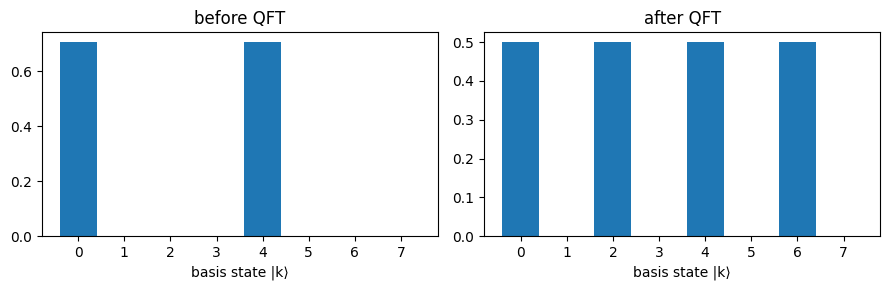

In [4]:
n = 3
q = QuantumState(n)
q.amps[:] = 0.0
for k in (0, 4):
    q.amps[k] = 1.0
q.amps /= np.linalg.norm(q.amps)
before = np.abs(q.amps).copy()
qft(q, list(range(n)))
after = np.abs(q.amps)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(range(8), before)
axes[0].set_title('before QFT')
axes[0].set_xlabel('basis state |k⟩')
axes[1].bar(range(8), after)
axes[1].set_title('after QFT')
axes[1].set_xlabel('basis state |k⟩')
plt.tight_layout()
plt.show()

## 비공식적으로 본 Shor의 레시피

$f(x) = a^x \bmod N$에 대해 중첩 $\sum_x |x\rangle|f(x)\rangle$을 준비할 수 있다면, $y$ 레지스터에는 주기적인 패턴이 담깁니다(주기 = $a$의 $N$에 대한 order). $y$를 측정하면 고정된 값으로 붕괴되면서, $x$ 레지스터에는 그 주기에 대응하는 빗살 모양 중첩이 남습니다. 여기에 QFT를 적용하면 $2^n / r$의 배수 지점에 peak가 드러나며, 이를 연분수(continued fractions)로 풀면 $r$을 복원할 수 있습니다.

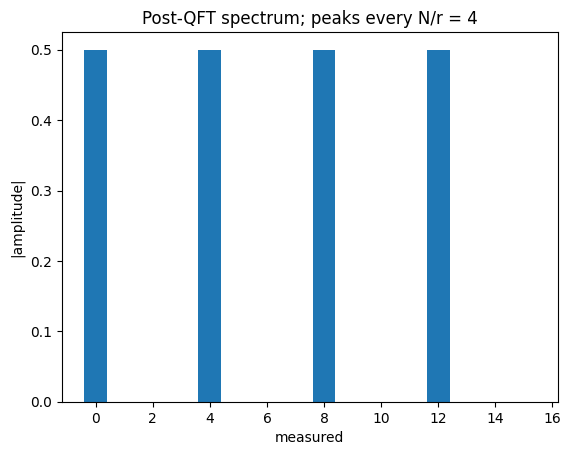

In [5]:
n = 4
q = QuantumState(n)
q.amps[:] = 0.0
period = 4
indices = list(range(0, 16, period))
for k in indices:
    q.amps[k] = 1.0
q.amps /= np.linalg.norm(q.amps)
qft(q, list(range(n)))
plt.bar(range(16), np.abs(q.amps))
plt.xlabel('measured')
plt.ylabel('|amplitude|')
plt.title(f'Post-QFT spectrum; peaks every N/r = {16//period}')
plt.show()

## 다음 이야기

이제 모든 조각이 갖춰졌습니다. 다음 노트북에서는 이 조각들을 모아 Shor 알고리즘을 완성하고, RSA 크기의 장난감 숫자들이 무너지는 모습을 지켜봅니다. → `14_shor_breaks_rsa.ipynb`